# Phase 4: Router — REINFORCE Training

Reinforcement learning for the Router agent using REINFORCE (policy gradient).

Outline
- 4.1 Imports & environment setup
- 4.2 Router CNN (policy + value heads)
- 4.3 REINFORCE training loop
- 4.4 Training curves
- 4.5 MCTS implementation
- 4.6 Evaluation (greedy + MCTS)
- 4.7 Save checkpoint

## Imports and Environment Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
from copy import deepcopy
from typing import List, Tuple, Optional, Dict
from routing_env import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

gymnasium available
NumPy: 2.2.6
All imports OK
Grid: 5×5  |  Nets: 3  |  Channels: 7
State tensor shape: (7, 5, 5)
Device: cuda


In [2]:
# Strict overlap helper
def compute_overlaps_strict(state, nets):
    pin_cells = {cell for src, snk in nets for cell in (src, snk)}
    congestion = state[C_CONGESTION]
    return sum(
        1 for r in range(GRID_SIZE) for c in range(GRID_SIZE)
        if congestion[r, c] > 1 and (r, c) not in pin_cells
    )

# Load working configs
all_configs_m2 = generate_net_configs(min_manhattan=2, seed=42)
all_configs = []
for cfg in all_configs_m2:
    nets  = deepcopy(cfg)
    paths = route_all_nets_astar(GRID_SIZE, nets)
    state = build_state_tensor(nets, paths, GRID_SIZE)
    if compute_overlaps_strict(state, nets) > 0:
        all_configs.append(cfg)

print(f'Working configs: {len(all_configs)}')

# Train / val / test split
rng  = np.random.default_rng(42)
idx  = rng.permutation(len(all_configs))
n_tr = int(0.7 * len(idx))
n_vl = int(0.15 * len(idx))
train_cfgs = [all_configs[i] for i in idx[:n_tr]]
val_cfgs   = [all_configs[i] for i in idx[n_tr:n_tr+n_vl]]
test_cfgs  = [all_configs[i] for i in idx[n_tr+n_vl:]]
print(f'Train:{len(train_cfgs)}  Val:{len(val_cfgs)}  Test:{len(test_cfgs)}')

Working configs: 5000
Train:3500  Val:750  Test:750


In [3]:
# Routing environment for RL episodes
class RouterEnv:
    """
    Single-net routing environment for the Router agent.

    The agent navigates from src to snk on a GRID_SIZE x GRID_SIZE grid,
    avoiding cells occupied by other nets.

    Rewards:
      +10   reaching the sink
      -0.1  each step (encourages shorter paths)
       -5   attempting an illegal move (blocked or out of bounds)
      -10   timeout (max_steps exceeded)
    """
    def __init__(self, nets, partial_paths, net_idx, grid_size=GRID_SIZE):
        self.nets          = nets
        self.partial_paths = partial_paths
        self.net_idx       = net_idx
        self.grid_size     = grid_size
        self.src, self.snk = nets[net_idx]
        self.max_steps     = grid_size * grid_size

        # Blocked cells from other nets
        self.blocked = set()
        for i, p in enumerate(partial_paths):
            if p and i != net_idx:
                for cell in p:
                    self.blocked.add(cell)
        self.blocked.discard(self.src)
        self.blocked.discard(self.snk)

        self.reset()

    def reset(self):
        self.current  = self.src
        self.path     = [self.current]
        self.visited  = {self.current}
        self.steps    = 0
        self.done     = False
        return self._get_state()

    def step(self, action):
        assert not self.done, 'Episode is done — call reset()'
        self.steps += 1

        dr, dc = ACTIONS[action]
        nr, nc = self.current[0] + dr, self.current[1] + dc
        nxt    = (nr, nc)

        # Illegal move
        if (not (0 <= nr < self.grid_size and 0 <= nc < self.grid_size)
                or nxt in self.blocked
                or nxt in self.visited):
            reward    = -5.0
            self.done = True
            return self._get_state(), reward, self.done, {'success': False}

        # Valid move
        self.current = nxt
        self.path.append(nxt)
        self.visited.add(nxt)

        if nxt == self.snk:
            reward    = 10.0
            self.done = True
            return self._get_state(), reward, self.done, {'success': True}

        if self.steps >= self.max_steps:
            reward    = -10.0
            self.done = True
            return self._get_state(), reward, self.done, {'success': False}

        # Step penalty + distance shaping
        dist_after  = abs(nxt[0]-self.snk[0]) + abs(nxt[1]-self.snk[1])
        max_dist    = 2 * (self.grid_size - 1)
        reward      = -0.1 + 0.5 * (1.0 - dist_after / max_dist)
        return self._get_state(), reward, self.done, {'success': False}

    def _get_state(self):
        """Build state tensor reflecting current path progress."""
        temp = deepcopy(self.partial_paths)
        temp[self.net_idx] = self.path
        return build_state_tensor(self.nets, temp, self.grid_size)

    def get_valid_actions(self):
        valid = []
        for a, (dr, dc) in ACTIONS.items():
            nr, nc = self.current[0]+dr, self.current[1]+dc
            if (0 <= nr < self.grid_size and 0 <= nc < self.grid_size
                    and (nr,nc) not in self.blocked
                    and (nr,nc) not in self.visited):
                valid.append(a)
        return valid


# Smoke test
cfg0   = train_cfgs[0]
nets0  = deepcopy(cfg0)
paths0 = route_all_nets_astar(GRID_SIZE, nets0)
pp0    = deepcopy(paths0); pp0[0] = None
env0   = RouterEnv(nets0, pp0, net_idx=0)
s0     = env0.reset()
print(f'RouterEnv OK')
print(f'  State shape    : {s0.shape}')
print(f'  Valid actions  : {env0.get_valid_actions()}')
_, r, done, info = env0.step(1)
print(f'  After step     : reward={r:.2f}  done={done}  info={info}')

RouterEnv OK
  State shape    : (7, 5, 5)
  Valid actions  : []
  After step     : reward=-5.00  done=True  info={'success': False}


## 4.2: Router CNN (Policy + Value Heads)

In [4]:
NUM_ACTIONS = 4

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, padding=padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class RouterCNN(nn.Module):
    """
    Policy-gradient Router CNN.

    Policy head : softmax over 4 actions — used by REINFORCE
    Value head  : scalar baseline V(s) — reduces variance in REINFORCE
    """
    def __init__(self, in_channels=NUM_CHANNELS, num_actions=NUM_ACTIONS):
        super().__init__()
        self.backbone = nn.Sequential(
            ConvBlock(in_channels, 16), ConvBlock(16, 32),
            ConvBlock(32, 64),          ConvBlock(64, 128),
        )
        flat = 128 * GRID_SIZE * GRID_SIZE
        self.policy_head = nn.Sequential(
            nn.Linear(flat, 512), nn.ReLU(inplace=True),
            nn.Dropout(0.3),      nn.Linear(512, num_actions)
        )
        self.value_head = nn.Sequential(
            nn.Linear(flat, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.3),      nn.Linear(256, 1), nn.Tanh()
        )

    def forward(self, x):
        x = self.backbone(x).view(x.size(0), -1)
        return self.policy_head(x), self.value_head(x)

    def get_action(self, state_np, valid_actions=None):
        """
        Sample action from policy during training (stochastic).
        Masks invalid actions before sampling.
        Returns (action, log_prob, value).
        """
        self.eval()
        with torch.no_grad():
            x = torch.tensor(state_np, dtype=torch.float32).unsqueeze(0).to(device)
            logits, value = self(x)
            if valid_actions is not None and len(valid_actions) > 0:
                mask = torch.full((NUM_ACTIONS,), float('-inf')).to(device)
                for a in valid_actions:
                    mask[a] = 0.0
                logits = logits + mask.unsqueeze(0)
            dist     = Categorical(logits=logits)
            action   = dist.sample()
            log_prob = dist.log_prob(action)
        return action.item(), log_prob.item(), value.item()

    def predict(self, state_np):
        """Greedy prediction for evaluation (used by MCTS)."""
        self.eval()
        with torch.no_grad():
            x = torch.tensor(state_np, dtype=torch.float32).unsqueeze(0).to(device)
            p, v = self(x)
            return F.softmax(p, dim=1).cpu().numpy()[0], v.cpu().numpy()[0, 0]


router_model = RouterCNN().to(device)
dummy = torch.zeros(2, NUM_CHANNELS, GRID_SIZE, GRID_SIZE).to(device)
p_out, v_out = router_model(dummy)
print(f'RouterCNN OK — policy:{p_out.shape}  value:{v_out.shape}')
print(f'Parameters: {sum(p.numel() for p in router_model.parameters()):,}')

RouterCNN OK — policy:torch.Size([2, 4])  value:torch.Size([2, 1])
Parameters: 2,559,173


## 4.3: Reinforce training loop

In [5]:
# ── REINFORCE hyperparameters ─────────────────────────────────────────────
GAMMA          = 0.99
LR             = 5e-4
ENTROPY_COEF   = 0.01
VALUE_COEF     = 0.5
NUM_EPOCHS     = 50
EPISODES_EPOCH = 200
PATIENCE       = 15

optimizer = optim.Adam(router_model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)
os.makedirs('checkpoints', exist_ok=True)


def compute_returns(rewards, gamma=GAMMA):
    returns, G = [], 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    returns = torch.tensor(returns, dtype=torch.float32).to(device)
    if returns.std() > 1e-8:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return returns


def collect_episode(env):
    """Run one episode. Stores states and actions for later gradient computation."""
    state = env.reset()
    states, actions, rewards = [], [], []

    while not env.done:
        valid  = env.get_valid_actions()
        action, _, _ = router_model.get_action(state, valid)
        next_state, reward, done, info = env.step(action)
        states.append(state)
        actions.append(action)
        rewards.append(reward)
        state = next_state

    return states, actions, rewards, info.get('success', False)


def reinforce_update(states, actions, rewards):
    returns = compute_returns(rewards)

    router_model.train()
    all_log_probs, all_values = [], []

    for state, action in zip(states, actions):
        x = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        logits, value = router_model(x)
        # Clamp logits to prevent extreme values
        logits   = torch.clamp(logits, -10.0, 10.0)
        dist     = Categorical(logits=logits)
        log_prob = dist.log_prob(torch.tensor([action]).to(device))
        all_log_probs.append(log_prob)
        all_values.append(value.squeeze())

    log_probs_t = torch.stack(all_log_probs)
    values_t    = torch.stack(all_values)

    advantages  = returns - values_t.detach()
    # Normalize advantages
    if advantages.std() > 1e-8:
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    policy_loss = -(log_probs_t * advantages).mean()
    value_loss  = F.mse_loss(values_t, returns)
    entropy     = -(log_probs_t * torch.exp(log_probs_t)).mean()
    loss        = policy_loss + VALUE_COEF * value_loss - ENTROPY_COEF * entropy

    optimizer.zero_grad()
    loss.backward()
    # Tighter gradient clipping
    torch.nn.utils.clip_grad_norm_(router_model.parameters(), max_norm=0.5)
    optimizer.step()

    return loss.item(), policy_loss.item(), value_loss.item()

print('REINFORCE setup ready')
print(f'  Gamma          : {GAMMA}')
print(f'  LR             : {LR}')
print(f'  Entropy coef   : {ENTROPY_COEF}')
print(f'  Epochs         : {NUM_EPOCHS}')
print(f'  Episodes/epoch : {EPISODES_EPOCH}')

REINFORCE setup ready
  Gamma          : 0.99
  LR             : 0.0005
  Entropy coef   : 0.01
  Epochs         : 50
  Episodes/epoch : 200


In [6]:
# ── Hyperparameters ───────────────────────────────────────────────────────
GAMMA           = 0.99
LR              = 5e-4
RL_LR           = 1e-4
ENTROPY_COEF    = 0.01
VALUE_COEF      = 0.5
PRETRAIN_EPOCHS = 5
RL_EPOCHS       = 50
EPISODES_EPOCH  = 200
PATIENCE        = 20

optimizer    = optim.Adam(router_model.parameters(), lr=LR,    weight_decay=1e-5)
rl_optimizer = optim.Adam(router_model.parameters(), lr=RL_LR, weight_decay=1e-5)
scheduler    = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=PRETRAIN_EPOCHS + RL_EPOCHS, eta_min=1e-5)
ce_loss = nn.CrossEntropyLoss()
os.makedirs('checkpoints', exist_ok=True)


def compute_returns(rewards, gamma=GAMMA):
    returns, G = [], 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    returns = torch.tensor(returns, dtype=torch.float32).to(device)
    if returns.std() > 1e-8:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return returns


def collect_episode(env):
    state = env.reset()
    states, actions, rewards = [], [], []
    while not env.done:
        valid  = env.get_valid_actions()
        action, _, _ = router_model.get_action(state, valid)
        next_state, reward, done, info = env.step(action)
        states.append(state)
        actions.append(action)
        rewards.append(reward)
        state = next_state
    return states, actions, rewards, info.get('success', False)


def reinforce_update(states, actions, rewards):
    returns = compute_returns(rewards)
    router_model.train()
    all_log_probs, all_values = [], []
    for state, action in zip(states, actions):
        x = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        logits, value = router_model(x)
        logits   = torch.clamp(logits, -10.0, 10.0)
        dist     = Categorical(logits=logits)
        log_prob = dist.log_prob(torch.tensor([action]).to(device))
        all_log_probs.append(log_prob)
        all_values.append(value.squeeze())
    log_probs_t = torch.stack(all_log_probs)
    values_t    = torch.stack(all_values)
    advantages  = returns - values_t.detach()
    if advantages.std() > 1e-8:
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    policy_loss = -(log_probs_t * advantages).mean()
    value_loss  = F.mse_loss(values_t, returns)
    entropy     = -(log_probs_t * torch.exp(log_probs_t)).mean()
    loss        = policy_loss + VALUE_COEF * value_loss - ENTROPY_COEF * entropy
    rl_optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(router_model.parameters(), max_norm=0.5)
    rl_optimizer.step()
    return loss.item(), policy_loss.item(), value_loss.item()


def pretrain_step(cfg):
    nets  = deepcopy(cfg)
    paths = route_all_nets_astar(GRID_SIZE, nets)
    state = build_state_tensor(nets, paths, GRID_SIZE)
    cong  = state[C_CONGESTION]
    ov    = [int(np.sum((state[C_PATH_START+i]>0) & (cong>1)))
             for i in range(NUM_NETS)]
    net_rem = int(np.argmax(ov)) if max(ov) > 0 else int(rng.integers(0, NUM_NETS))
    partial          = deepcopy(paths)
    partial[net_rem] = None
    blocked = set(c for i,p in enumerate(partial) if p and i!=net_rem for c in p)
    src, snk = nets[net_rem]
    blocked.discard(src); blocked.discard(snk)
    astar_path = astar(GRID_SIZE, src, snk, blocked=blocked)
    if astar_path is None or len(astar_path) < 2:
        return None
    action_map = {(-1,0):0,(1,0):1,(0,-1):2,(0,1):3}
    total_loss = 0.0
    cur_path   = [src]
    router_model.train()
    for i in range(len(astar_path)-1):
        temp = deepcopy(partial); temp[net_rem] = cur_path
        cur_state = build_state_tensor(nets, temp, GRID_SIZE)
        dr = astar_path[i+1][0] - astar_path[i][0]
        dc = astar_path[i+1][1] - astar_path[i][1]
        target = action_map.get((dr,dc), 0)
        x      = torch.tensor(cur_state, dtype=torch.float32).unsqueeze(0).to(device)
        logits, _ = router_model(x)
        loss   = ce_loss(logits, torch.tensor([target]).to(device))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(router_model.parameters(), max_norm=0.5)
        optimizer.step()
        total_loss += loss.item()
        cur_path.append(astar_path[i+1])
    return total_loss / (len(astar_path)-1)


print(f'Phase 1: Supervised warm-start for {PRETRAIN_EPOCHS} epochs...')
print(f'{"Epoch":>6} {"Loss":>10} {"Val Succ":>10}')

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    losses = []
    epoch_cfgs = [train_cfgs[i % len(train_cfgs)]
                  for i in rng.integers(0, len(train_cfgs), EPISODES_EPOCH)]
    for cfg in epoch_cfgs:
        l = pretrain_step(cfg)
        if l is not None:
            losses.append(l)
    router_model.eval()
    val_succ = []
    for cfg in val_cfgs[:100]:
        nets    = deepcopy(cfg)
        paths   = route_all_nets_astar(GRID_SIZE, nets)
        state   = build_state_tensor(nets, paths, GRID_SIZE)
        cong    = state[C_CONGESTION]
        ov      = [int(np.sum((state[C_PATH_START+i]>0) & (cong>1)))
                   for i in range(NUM_NETS)]
        net_rem = int(np.argmax(ov)) if max(ov) > 0 else 0
        partial = deepcopy(paths); partial[net_rem] = None
        env     = RouterEnv(nets, partial, net_idx=net_rem)
        _, _, _, success = collect_episode(env)
        val_succ.append(float(success))
    scheduler.step()
    print(f'{epoch:>6} {np.mean(losses):>10.4f} {np.mean(val_succ)*100:>9.1f}%')

print(f'\nWarm-start complete.')
print(f'\nPhase 2: REINFORCE fine-tuning for {RL_EPOCHS} epochs...')
print(f'{"Epoch":>6} {"Success":>9} {"Val Succ":>10} {"Avg Ret":>9} {"P-Loss":>8} {"V-Loss":>8}')

history = {
    'epoch': [], 'success_rate': [], 'val_success_rate': [],
    'avg_return': [], 'policy_loss': [], 'value_loss': []
}
best_val_success = 0.0
patience_count   = 0

for epoch in range(1, RL_EPOCHS + 1):
    router_model.train()
    ep_successes, ep_returns = [], []
    p_losses, v_losses       = [], []
    epoch_cfgs = [train_cfgs[i % len(train_cfgs)]
                  for i in rng.integers(0, len(train_cfgs), EPISODES_EPOCH)]
    for cfg in epoch_cfgs:
        nets  = deepcopy(cfg)
        paths = route_all_nets_astar(GRID_SIZE, nets)
        state = build_state_tensor(nets, paths, GRID_SIZE)
        cong  = state[C_CONGESTION]
        ov    = [int(np.sum((state[C_PATH_START+i]>0) & (cong>1)))
                 for i in range(NUM_NETS)]
        net_rem = int(np.argmax(ov)) if max(ov) > 0 else int(rng.integers(0, NUM_NETS))
        partial          = deepcopy(paths)
        partial[net_rem] = None
        env = RouterEnv(nets, partial, net_idx=net_rem)
        states, actions, rewards, success = collect_episode(env)
        if len(states) > 0:
            loss, pl, vl = reinforce_update(states, actions, rewards)
            p_losses.append(pl)
            v_losses.append(vl)
        ep_successes.append(float(success))
        ep_returns.append(sum(rewards))
    scheduler.step()
    router_model.eval()
    val_successes = []
    for cfg in val_cfgs[:100]:
        nets    = deepcopy(cfg)
        paths   = route_all_nets_astar(GRID_SIZE, nets)
        state   = build_state_tensor(nets, paths, GRID_SIZE)
        cong    = state[C_CONGESTION]
        ov      = [int(np.sum((state[C_PATH_START+i]>0) & (cong>1)))
                   for i in range(NUM_NETS)]
        net_rem = int(np.argmax(ov)) if max(ov) > 0 else 0
        partial = deepcopy(paths); partial[net_rem] = None
        env     = RouterEnv(nets, partial, net_idx=net_rem)
        _, _, _, success = collect_episode(env)
        val_successes.append(float(success))
    train_succ = float(np.mean(ep_successes))
    val_succ   = float(np.mean(val_successes))
    avg_ret    = float(np.mean(ep_returns))
    avg_pl     = float(np.mean(p_losses)) if p_losses else 0.0
    avg_vl     = float(np.mean(v_losses)) if v_losses else 0.0
    history['epoch'].append(epoch)
    history['success_rate'].append(train_succ)
    history['val_success_rate'].append(val_succ)
    history['avg_return'].append(avg_ret)
    history['policy_loss'].append(avg_pl)
    history['value_loss'].append(avg_vl)
    flag = ''
    if val_succ > best_val_success:
        best_val_success = val_succ
        patience_count   = 0
        torch.save(router_model.state_dict(), 'checkpoints/router_best.pt')
        flag = ' <- best'
    else:
        patience_count += 1
    print(f'{epoch:>6} {train_succ*100:>8.1f}% {val_succ*100:>9.1f}% '
          f'{avg_ret:>9.2f} {avg_pl:>8.4f} {avg_vl:>8.4f}{flag}')
    if patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

print(f'\nRL fine-tuning complete. Best val success: {best_val_success*100:.1f}%')

Phase 1: Supervised warm-start for 5 epochs...
 Epoch       Loss   Val Succ
     1     1.7563      41.0%
     2     1.6683      51.0%
     3     1.2203      47.0%
     4     1.1516      46.0%
     5     0.7332      53.0%

Warm-start complete.

Phase 2: REINFORCE fine-tuning for 50 epochs...
 Epoch   Success   Val Succ   Avg Ret   P-Loss   V-Loss


/tmp/ipykernel_2733064/1494451224.py:26: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  if returns.std() > 1e-8:
/tmp/ipykernel_2733064/1494451224.py:60: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  if advantages.std() > 1e-8:


     1     45.5%      53.0%      2.65  -0.1205   3.2686 <- best
     2     46.0%      46.0%      2.74  -0.4467   2.8468
     3     42.0%      45.0%      2.17  -0.8944   3.3987
     4     37.5%      30.0%      1.42  -0.8597   3.4277
     5     33.0%      42.0%      0.76  -1.3333   4.2318
     6     34.0%      35.0%      0.91  -0.7575   3.1491
     7     29.0%      28.0%      0.24  -1.1289   3.4210
     8     29.5%      30.0%      0.30  -0.9412   2.5406
     9     30.0%      32.0%      0.42  -1.0277   2.7336
    10     32.0%      36.0%      0.70  -0.6354   2.7575
    11     28.5%      29.0%      0.15  -0.6625   2.9477
    12     31.5%      31.0%      0.54  -1.3199   3.4206
    13     29.0%      23.0%      0.25  -0.9330   3.5711
    14     31.5%      35.0%      0.62  -0.7933   3.6316
    15     25.0%      23.0%     -0.26  -0.6982   2.7839
    16     24.0%      35.0%     -0.46  -1.1556   3.8063
    17     34.0%      32.0%      1.02  -1.6084   3.8386
    18     29.0%      19.0%      0.42  -

## 4.4: Training curves

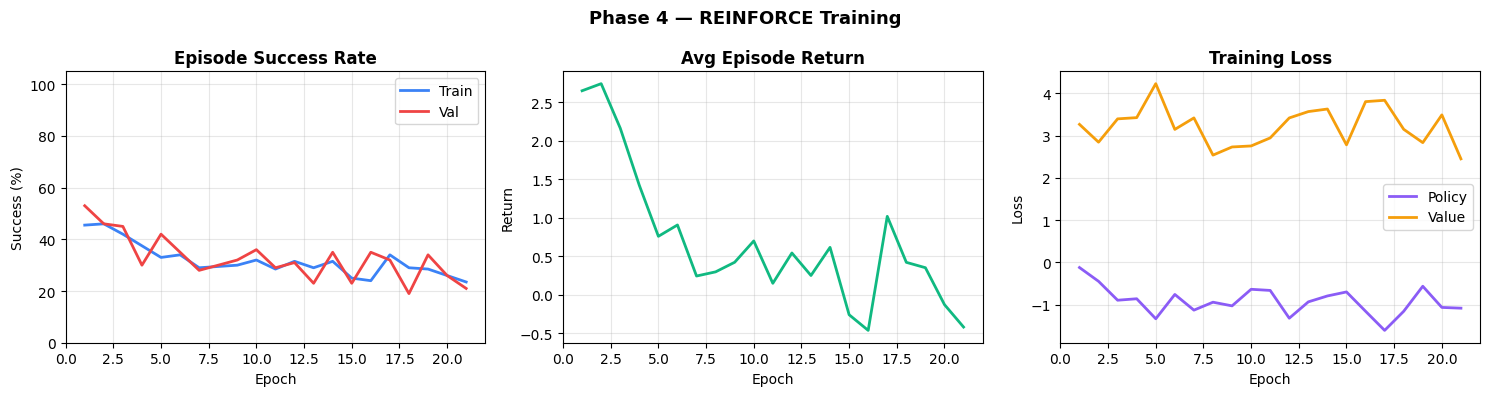

In [7]:
epochs = history['epoch']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Phase 4 — REINFORCE Training', fontsize=13, fontweight='bold')

axes[0].plot(epochs, [x*100 for x in history['success_rate']],
             color='#3B82F6', linewidth=2, label='Train')
axes[0].plot(epochs, [x*100 for x in history['val_success_rate']],
             color='#EF4444', linewidth=2, label='Val')
axes[0].set_title('Episode Success Rate', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Success (%)')
axes[0].set_ylim(0, 105); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['avg_return'],
             color='#10B981', linewidth=2)
axes[1].set_title('Avg Episode Return', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Return')
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['policy_loss'],
             color='#8B5CF6', linewidth=2, label='Policy')
axes[2].plot(epochs, history['value_loss'],
             color='#F59E0B', linewidth=2, label='Value')
axes[2].set_title('Training Loss', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase4_reinforce_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 4.5: MCTS Implementation

In [8]:
class MCTSNode:
    def __init__(self, position, parent=None, prior=0.0, action=None):
        self.position = position
        self.parent   = parent
        self.action   = action
        self.prior    = prior
        self.children: Dict = {}
        self.N = 0
        self.W = 0.0

    @property
    def Q(self):
        return self.W / self.N if self.N > 0 else 0.0

    def is_leaf(self):
        return len(self.children) == 0

    def ucb_score(self, c_puct=1.4):
        if self.parent is None:
            return 0.0
        return self.Q + c_puct * self.prior * math.sqrt(self.parent.N) / (1 + self.N)


class MCTS:
    """
    MCTS guided by the trained Router CNN policy.
    Used at inference time to improve routing decisions.
    """
    def __init__(self, model, grid_size=GRID_SIZE, c_puct=1.4, num_simulations=50):
        self.model           = model
        self.grid_size       = grid_size
        self.c_puct          = c_puct
        self.num_simulations = num_simulations

    def search(self, state, start, sink, blocked, path_so_far):
        root   = MCTSNode(position=start)
        priors, _ = self.model.predict(state)
        self._expand(root, priors, blocked, set(path_so_far))
        for _ in range(self.num_simulations):
            node  = self._select(root)
            value = self._evaluate(node, state, sink)
            self._backpropagate(node, value)
        if not root.children:
            return np.random.randint(NUM_ACTIONS)
        return max(root.children, key=lambda a: root.children[a].N)

    def _select(self, node):
        while not node.is_leaf():
            node = max(node.children.values(),
                       key=lambda n: n.ucb_score(self.c_puct))
        return node

    def _expand(self, node, priors, blocked, visited):
        r, c = node.position
        for action, (dr, dc) in ACTIONS.items():
            nr, nc   = r+dr, c+dc
            neighbor = (nr, nc)
            if not (0 <= nr < self.grid_size and 0 <= nc < self.grid_size):
                continue
            if neighbor in blocked or neighbor in visited:
                continue
            node.children[action] = MCTSNode(
                position=neighbor, parent=node,
                prior=priors[action], action=action)

    def _evaluate(self, node, state, sink):
        if node.position == sink:
            return 1.0
        _, value   = self.model.predict(state)
        r, c       = node.position
        sr, sc     = sink
        dist       = abs(r-sr) + abs(c-sc)
        dist_bonus = 1.0 - dist / (2*(self.grid_size-1))
        return 0.7 * float(value) + 0.3 * dist_bonus

    def _backpropagate(self, node, value):
        while node is not None:
            node.N += 1
            node.W += value
            node    = node.parent


def mcts_route(model, nets, partial_paths, net_idx, num_simulations=50):
    """Route net_idx using MCTS guided by Router CNN policy."""
    src, snk = nets[net_idx]
    mcts     = MCTS(model, num_simulations=num_simulations)
    blocked  = set()
    for i, p in enumerate(partial_paths):
        if p and i != net_idx:
            for cell in p: blocked.add(cell)
    blocked.discard(src); blocked.discard(snk)

    current, path, visited = src, [src], {src}
    for _ in range(GRID_SIZE * GRID_SIZE):
        if current == snk: return path
        temp = deepcopy(partial_paths); temp[net_idx] = path
        cur_state = build_state_tensor(nets, temp, GRID_SIZE)
        valid = [a for a,(dr,dc) in ACTIONS.items()
                 if 0<=current[0]+dr<GRID_SIZE and 0<=current[1]+dc<GRID_SIZE
                 and (current[0]+dr,current[1]+dc) not in blocked
                 and (current[0]+dr,current[1]+dc) not in visited]
        if not valid: break
        action = mcts.search(cur_state, current, snk, blocked, path)
        dr, dc = ACTIONS[action]
        nxt    = (current[0]+dr, current[1]+dc)
        if nxt in blocked or nxt in visited or not (
                0<=nxt[0]<GRID_SIZE and 0<=nxt[1]<GRID_SIZE):
            nxt = min([(current[0]+ACTIONS[a][0], current[1]+ACTIONS[a][1])
                       for a in valid],
                      key=lambda p: abs(p[0]-snk[0])+abs(p[1]-snk[1]))
        path.append(nxt); visited.add(nxt); current = nxt
    return path if current == snk else astar(GRID_SIZE, src, snk, blocked=blocked)


def greedy_route(model, nets, partial_paths, net_idx):
    """Route net_idx using greedy policy. Falls back to A* if stuck."""
    src, snk = nets[net_idx]
    blocked  = set()
    for i, p in enumerate(partial_paths):
        if p and i != net_idx:
            for cell in p: blocked.add(cell)
    blocked.discard(src); blocked.discard(snk)
    current, path, visited = src, [src], {src}
    for _ in range(GRID_SIZE * GRID_SIZE):
        if current == snk: return path
        temp = deepcopy(partial_paths); temp[net_idx] = path
        cur_state = build_state_tensor(nets, temp, GRID_SIZE)
        valid = [a for a,(dr,dc) in ACTIONS.items()
                 if 0<=current[0]+dr<GRID_SIZE and 0<=current[1]+dc<GRID_SIZE
                 and (current[0]+dr,current[1]+dc) not in blocked
                 and (current[0]+dr,current[1]+dc) not in visited]
        if not valid: break
        probs, _ = model.predict(cur_state)
        a   = max(valid, key=lambda x: probs[x])
        dr, dc = ACTIONS[a]
        nxt = (current[0]+dr, current[1]+dc)
        path.append(nxt); visited.add(nxt); current = nxt
    return path if current == snk else astar(GRID_SIZE, src, snk, blocked=blocked)


print('MCTS and greedy routing ready')

MCTS and greedy routing ready


## 4.6: Evaluation

In [9]:
# Load best checkpoint
router_model.load_state_dict(
    torch.load('checkpoints/router_best.pt', map_location=device))
router_model.eval()


def evaluate_pipeline(configs, router, use_mcts=False, num_simulations=50):
    """Evaluate Router on configs using greedy or MCTS routing."""
    completed, total, wirelengths = 0, 0, []

    for cfg in configs:
        nets  = deepcopy(cfg)
        paths = route_all_nets_astar(GRID_SIZE, nets)
        state = build_state_tensor(nets, paths, GRID_SIZE)
        if compute_overlaps_strict(state, nets) == 0:
            continue
        total += 1

        rl_paths = deepcopy(paths)
        for _ in range(3):
            s = build_state_tensor(nets, rl_paths, GRID_SIZE)
            if compute_overlaps_strict(s, nets) == 0:
                break
            cong    = s[C_CONGESTION]
            ov      = [int(np.sum((s[C_PATH_START+i]>0) & (cong>1)))
                       for i in range(NUM_NETS)]
            net_rem = int(np.argmax(ov))
            rl_paths[net_rem] = None
            if use_mcts:
                new_path = mcts_route(router, nets, rl_paths, net_rem, num_simulations)
            else:
                new_path = greedy_route(router, nets, rl_paths, net_rem)
            if new_path:
                rl_paths[net_rem] = new_path

        s = build_state_tensor(nets, rl_paths, GRID_SIZE)
        if compute_overlaps_strict(s, nets) == 0 and all(rl_paths):
            completed += 1
            wirelengths.append(compute_total_wirelength(rl_paths))

    rate = completed / total if total > 0 else 0.0
    return rate, float(np.mean(wirelengths)) if wirelengths else None, total


print('Evaluating Router (greedy)...')
g_rate, g_wl, g_total = evaluate_pipeline(test_cfgs, router_model, use_mcts=False)
print(f'  Greedy completion : {g_rate*100:.1f}%')
print(f'  Greedy avg WL     : {g_wl:.2f}' if g_wl else '  Greedy avg WL : N/A')

print('\nEvaluating Router (MCTS, 50 sims)...')
m_rate, m_wl, _ = evaluate_pipeline(test_cfgs, router_model, use_mcts=True, num_simulations=50)
print(f'  MCTS completion   : {m_rate*100:.1f}%')
print(f'  MCTS avg WL       : {m_wl:.2f}' if m_wl else '  MCTS avg WL   : N/A')

print(f'\nMCTS improvement  : +{(m_rate-g_rate)*100:.1f}%')

Evaluating Router (greedy)...
  Greedy completion : 55.9%
  Greedy avg WL     : 12.45

Evaluating Router (MCTS, 50 sims)...
  MCTS completion   : 55.9%
  MCTS avg WL       : 12.51

MCTS improvement  : +0.0%


In [ ]:
checkpoint = {
    'model_state_dict': router_model.state_dict(),
    'history':          history,
    'best_val_success': best_val_success,
    'config': {
        'algorithm':       'REINFORCE',
        'gamma':           GAMMA,
        'lr':              LR,
        'entropy_coef':    ENTROPY_COEF,
        'value_coef':      VALUE_COEF,
        'num_epochs':      NUM_EPOCHS,
        'episodes_epoch':  EPISODES_EPOCH,
        'grid_size':       GRID_SIZE,
    }
}
torch.save(checkpoint, 'checkpoints/router_final.pt')
print('Full checkpoint saved → checkpoints/router_final.pt')
print()
print('=' * 52)
print('  Phase 4 Summary — REINFORCE Router')
print('=' * 52)
print(f'  Algorithm        : REINFORCE + value baseline')
print(f'  Parameters       : {sum(p.numel() for p in router_model.parameters()):,}')
print(f'  Best val success : {best_val_success*100:.1f}%')
print(f'  Greedy routing   : {g_rate*100:.1f}% completion')
print(f'  MCTS routing     : {m_rate*100:.1f}% completion')
print(f'  Checkpoint       : checkpoints/router_best.pt')
print()
print('  → Ready for Phase 5: Co-Training & Evaluation')